First, we merge eight individual output files into one file called "prior_sensitivity_results_all_channels.csv"

In [1]:
import pandas as pd
from pathlib import Path

# Use the notebook's current working directory as the base folder
BASE_DIR = Path.cwd()

channel_order = [
    "meta",
    "google",
    "snapchat",
    "tiktok",
    "moloco",
    "liveintent",
    "beehiiv",
    "amazon"
]

all_dfs = []
missing = []

for channel in channel_order:
    file_path = BASE_DIR / f"prior_sensitivity_results_{channel}.csv"
    if not file_path.exists():
        missing.append(str(file_path))
        continue
    df = pd.read_csv(file_path)
    df["channel"] = channel
    all_dfs.append(df)

if missing:
    print("Missing files:\n" + "\n".join(missing))
if not all_dfs:
    raise FileNotFoundError("No CSV files found for the specified channels.")

merged_df = pd.concat(all_dfs, ignore_index=True)

merged_df.head()

,channel,estimated_roi,target_channel,roi_prior_mu,roi_prior_sigma,roi_prior_dist
0,meta,0.017757,meta,0.020759,0.006689,Normal
1,meta,0.062721,meta,0.020759,0.006689,Normal
2,meta,-0.106932,meta,0.020759,0.006689,Normal
3,meta,-0.083856,meta,0.020759,0.006689,Normal
4,meta,0.083206,meta,0.020759,0.006689,Normal


In [2]:
output_path = BASE_DIR / "prior_sensitivity_results_all_channels.csv"

merged_df.to_csv(output_path, index=False)

print(f"Saved merged file to: {output_path}")

Saved merged file to: /Users/jimmywu/Desktop/Base stage Visualization/prior_sensitivity_results_all_channels.csv


Next, we begin the visualization.

# Heatmap

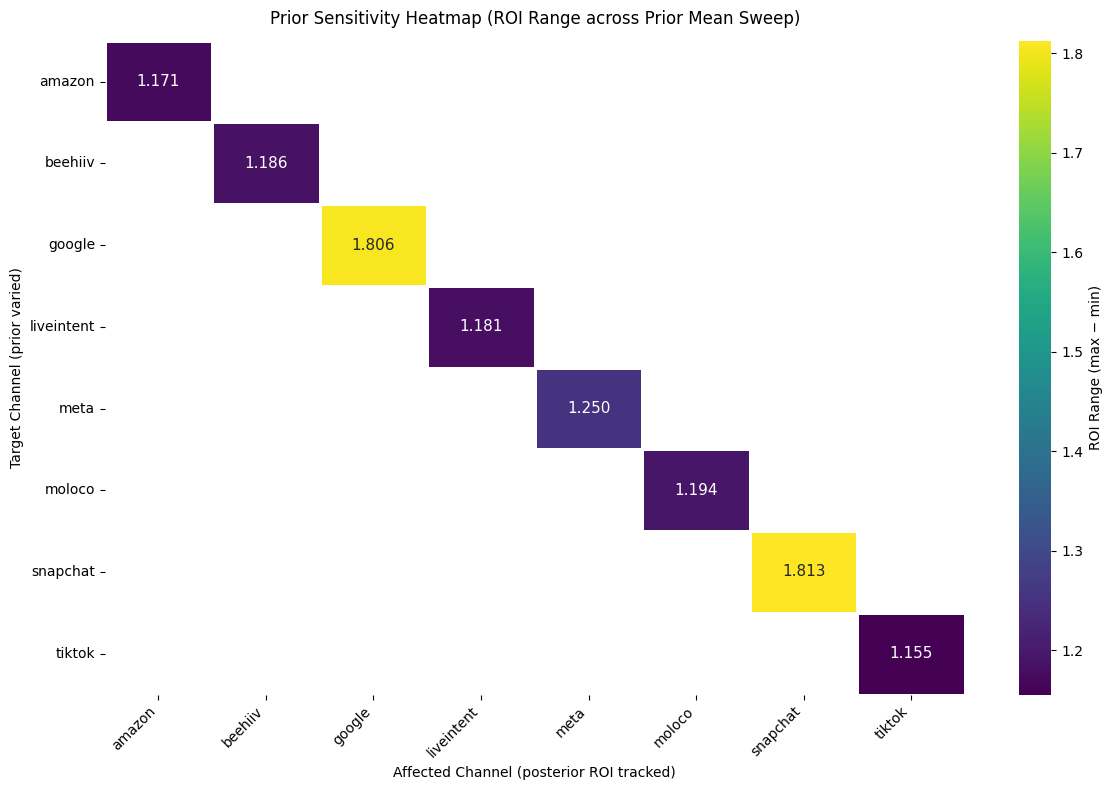

Saved: /Users/jimmywu/Desktop/Base stage Visualization/figures/Heatmap/prior_sensitivity_heatmap.png
Saved: /Users/jimmywu/Desktop/Base stage Visualization/figures/Heatmap/prior_sensitivity_heatmap.pdf


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

df = pd.read_csv(Path.cwd() / "prior_sensitivity_results_all_channels.csv")

ranges = (
    df.groupby(["target_channel", "channel"], as_index=False)["estimated_roi"]
      .agg(roi_range=lambda x: x.max() - x.min())
)

pivot = ranges.pivot(index="target_channel", columns="channel", values="roi_range")
mask = pivot.isna()
pivot = pivot.where(np.eye(pivot.shape[0], pivot.shape[1], dtype=bool))

plt.figure(figsize=(12, 8))
ax = sns.heatmap(
    pivot,
    annot=True,
    fmt=".3f",
    cmap="viridis",
    linewidths=0.8,
    linecolor="white",
    mask=mask,           
    cbar_kws={"label": "ROI Range (max − min)"},
    annot_kws={"size": 11}
)

ax.set_title("Prior Sensitivity Heatmap (ROI Range across Prior Mean Sweep)", pad=12)
ax.set_xlabel("Affected Channel (posterior ROI tracked)")
ax.set_ylabel("Target Channel (prior varied)")

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()

out_dir = Path.cwd() / "figures" / "Heatmap"
out_dir.mkdir(exist_ok=True)

png_path = out_dir / "prior_sensitivity_heatmap.png"
pdf_path = out_dir / "prior_sensitivity_heatmap.pdf"
plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")

plt.show()

print("Saved:", png_path)
print("Saved:", pdf_path)


# Prior Sensitivity Ranking

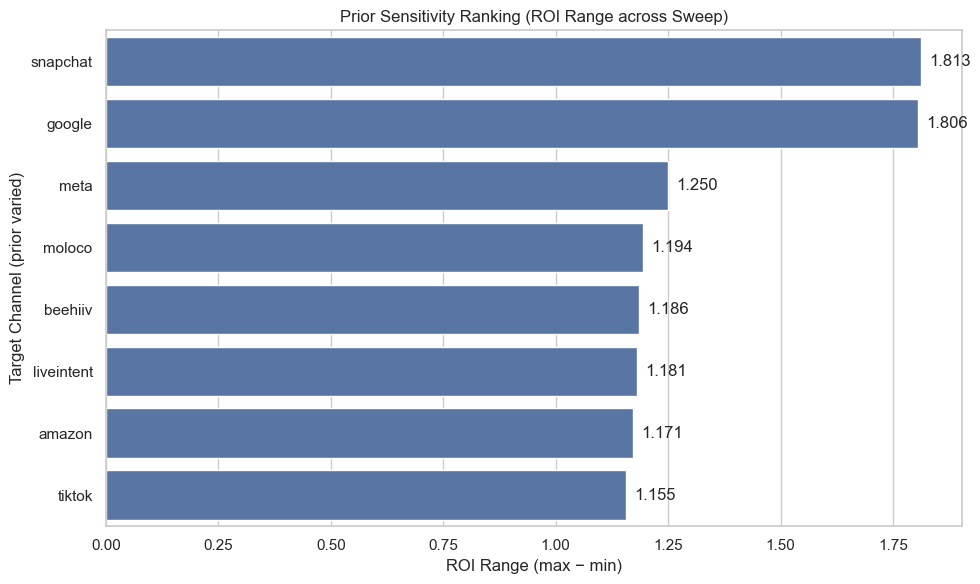

Saved: /Users/jimmywu/Desktop/Base stage Visualization/figures/Sensitivity Ranking/prior_sensitivity_ranking.png
Saved: /Users/jimmywu/Desktop/Base stage Visualization/figures/Sensitivity Ranking/prior_sensitivity_ranking.pdf


In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path


df = pd.read_csv(Path.cwd() / "prior_sensitivity_results_all_channels.csv")

REQ = {"target_channel", "channel", "estimated_roi"}
missing = REQ - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}\nFound: {df.columns.tolist()}")

df["estimated_roi"] = pd.to_numeric(df["estimated_roi"], errors="coerce")
df = df.dropna(subset=["estimated_roi", "target_channel", "channel"])


diag_only = True

if diag_only:
    df_use = df[df["target_channel"].astype(str) == df["channel"].astype(str)].copy()
else:
    df_use = df.copy()

sensitivity = (
    df_use.groupby("target_channel")["estimated_roi"]
          .agg(lambda x: np.nanmax(x) - np.nanmin(x))
          .reset_index(name="roi_range")
          .sort_values("roi_range", ascending=False)
)


sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=sensitivity, x="roi_range", y="target_channel", orient="h")

ax.set_title("Prior Sensitivity Ranking (ROI Range across Sweep)")
ax.set_xlabel("ROI Range (max − min)")
ax.set_ylabel("Target Channel (prior varied)")

for p in ax.patches:
    width = p.get_width()
    ax.text(width + 0.01 * sensitivity["roi_range"].max(),
            p.get_y() + p.get_height() / 2,
            f"{width:.3f}",
            va="center")

plt.tight_layout()

out_dir = Path.cwd() / "figures" / "Sensitivity Ranking"
out_dir.mkdir(exist_ok=True)

png_path = out_dir / "prior_sensitivity_ranking.png"
pdf_path = out_dir / "prior_sensitivity_ranking.pdf"

plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")

plt.show()

print("Saved:", png_path)
print("Saved:", pdf_path)
